In [1]:
# ==============================================================================
# SECTION 1: INSTALLATION AND SETUP
# ==============================================================================
# Install PyTorch and Detectron2
# Note: This may take a few minutes.
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

# Import necessary libraries
import torch
import detectron2
import os
import json
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

# Detectron2 utilities
from detectron2.utils.logger import setup_logger
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

# Setup logger
setup_logger()

print(f"PyTorch Version: {torch.__version__}")
print(f"Detectron2 Version: {detectron2.__version__}")

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')



  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-_2peil3c
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-_2peil3c
  Resolved https://github.com/facebookresearch/detectron2.git to commit 18f69583391e5040043ca4f4bebd2c60f0ebfde0
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.4 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp311-cp311-linux_x86_64.whl size=6434843 sha256=f079cc2910f0f6ed01777990cbbd78c2f1a3ccc9c489cea919c9e4d9d67f918b
  Stored in directory: /tmp/pip-ephem-wheel-cache-ni4ly_kl/wheels/17/d9/40/60db98e485aa9455

WARNING [07/19 12:26:06 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[07/19 12:26:06 d2.data.datasets.coco]: Loaded 197 images in COCO format from /content/drive/MyDrive/biotech/Retina_Lab/patches/coco_annotations_corrected.json

--- Verifying Dataset Registration ---
Registered 'cell_dataset_train' with 197 images.
Visualizing 3 random samples from the training set...


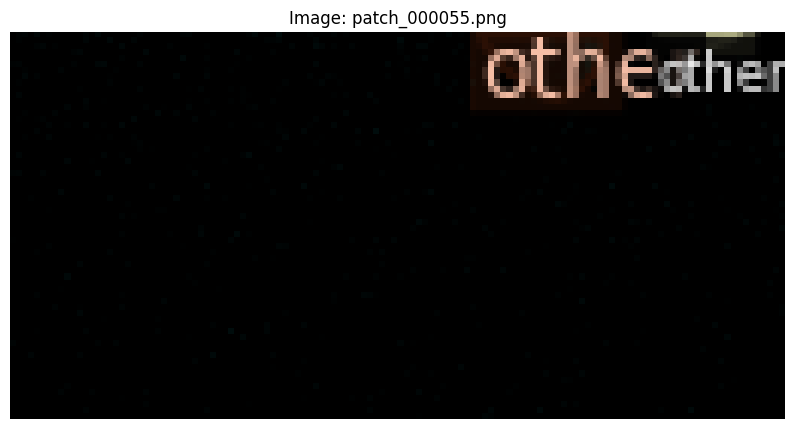

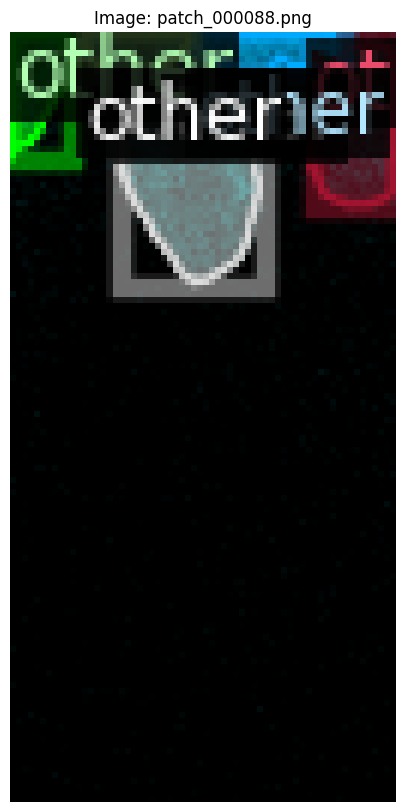

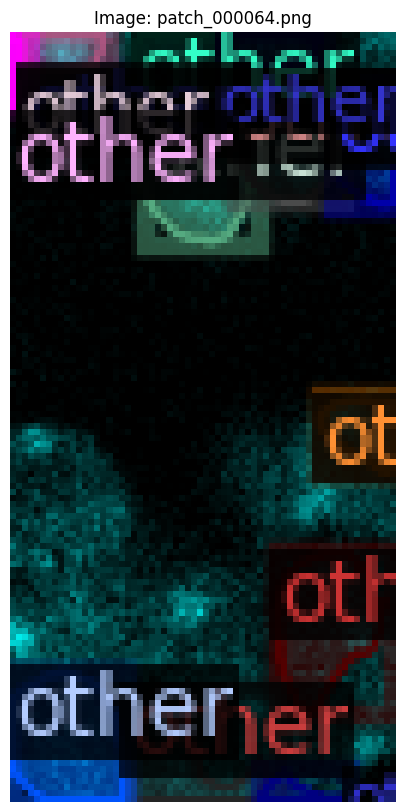

In [2]:
# ==============================================================================
# SECTION 2: DATASET REGISTRATION (Corrected)
# ==============================================================================
# Define paths as provided
annotations_path = "/content/drive/MyDrive/biotech/Retina_Lab/patches/coco_annotations.json"
image_root_path = "/content/drive/MyDrive/biotech/Retina_Lab/patches"
output_dir = "/content/drive/MyDrive/biotech/Retina_Lab/"
inference_image_path = "/content/drive/MyDrive/biotech/Retina_Lab/maskrcnn_approach/C1-C30000.png"

# Define dataset name and class labels
dataset_name = "cell_dataset_train"
class_labels = ["other", "rbc", "cbc"]

# --- CUSTOM DATA LOADER FUNCTION ---
# This function fixes the file paths in memory to match the folder structure.
import json # Import the json module
def get_cell_dicts(img_root, json_path):
    """
    Loads the COCO json file and corrects the file_name path for each image.
    The original json has file_name like "patches/some_folder/image.png",
    which creates a duplicate "patches" segment when joined with the image_root.
    This function removes the leading "patches/" from the file_name.
    """
    with open(json_path) as f:
        imgs_anns = json.load(f)

    # Correct the file_name path in the 'images' section
    for img_dict in imgs_anns["images"]:
        # Original: "patches/C1-C30000/patch_000001.png"
        # Corrected: "C1-C30000/patch_000001.png"
        if "patches/" in img_dict["file_name"]:
            img_dict["file_name"] = img_dict["file_name"].split("patches/", 1)[1]

    # Temporarily save the corrected annotations to a new file
    # This is the cleanest way to use it with `register_coco_instances`
    temp_json_path = os.path.join(os.path.dirname(json_path), "coco_annotations_corrected.json")
    with open(temp_json_path, 'w') as f:
        json.dump(imgs_anns, f)

    return temp_json_path

# Get the path to the corrected temporary annotations file
corrected_annotations_path = get_cell_dicts(image_root_path, annotations_path)

# Unregister the dataset if it already exists
if dataset_name in DatasetCatalog.list():
    DatasetCatalog.remove(dataset_name)
if dataset_name in MetadataCatalog.list():
    MetadataCatalog.remove(dataset_name)


# Register the COCO-style dataset using the corrected annotations
register_coco_instances(
    name=dataset_name,
    metadata={"thing_classes": class_labels},
    json_file=corrected_annotations_path,
    image_root=image_root_path
)

# Verify registration by visualizing a few samples
cell_metadata = MetadataCatalog.get(dataset_name)
dataset_dicts = DatasetCatalog.get(dataset_name)

print("\n--- Verifying Dataset Registration ---")
print(f"Registered '{dataset_name}' with {len(dataset_dicts)} images.")
print("Visualizing 3 random samples from the training set...")

for d in random.sample(dataset_dicts, 3):
    img = cv2.imread(d["file_name"])
    if img is None:
        print(f"Error: Could not read image at {d['file_name']}")
        continue # Skip to the next image if reading failed

    visualizer = Visualizer(img[:, :, ::-1], metadata=cell_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(vis.get_image()[:, :, ::-1], cv2.COLOR_BGR2RGB))
    plt.title(f"Image: {os.path.basename(d['file_name'])}")
    plt.axis('off')
    plt.show()

In [4]:
# ==============================================================================
# SECTION 3: MODEL CONFIGURATION AND TRAINING (Corrected)
# ==============================================================================
print("\n--- Configuring the Model for Training ---")

# Import model_zoo to access pre-trained models
from detectron2 import model_zoo

# Create a Detectron2 config object
cfg = get_cfg()

# Use a pre-trained Mask R-CNN model from the Detectron2 model zoo
# This is the corrected way to access the model zoo
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

# --- Dataset Configuration ---
cfg.DATASETS.TRAIN = (dataset_name,)
cfg.DATASETS.TEST = ()

# --- Dataloader Configuration ---
cfg.DATALOADER.NUM_WORKERS = 2

# --- Solver Configuration ---
# Batch size per GPU. Reduce if you face "CUDA out of memory" errors.
cfg.SOLVER.IMS_PER_BATCH = 4
# Base learning rate. A common starting point for fine-tuning.
cfg.SOLVER.BASE_LR = 0.00025
# Number of training iterations.
cfg.SOLVER.MAX_ITER = 3000
# Learning rate decay steps (no decay in this example).
cfg.SOLVER.STEPS = []

# --- Model Head Configuration ---
# Number of classes in the final layer (must match your dataset: other, rbc, cbc)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3
# Set batch size per image for RoI Heads training
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 256

# --- Output Configuration ---
cfg.OUTPUT_DIR = os.path.join(output_dir, "detectron2_output")
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

print(f"Model output will be saved to: {cfg.OUTPUT_DIR}")
print("Starting training... This may take a while. ⏳")

# Create a trainer instance and start training
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False) # Start training from scratch with pre-trained weights
trainer.train()

print("✅ Training complete!")


--- Configuring the Model for Training ---
Model output will be saved to: /content/drive/MyDrive/biotech/Retina_Lab/detectron2_output
Starting training... This may take a while. ⏳
[07/19 12:28:15 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1)

model_final_f10217.pkl: 178MB [00:03, 54.8MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[07/19 12:28:19 d2.engine.train_loop]: Starting training from iteration 0
ERROR [07/19 12:28:19 d2.engine.train_loop]: Exception during training:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/detectron2/engine/train_loop.py", line 155, in train
    self.run_step()
  File "/usr/local/lib/python3.11/dist-packages/detectron2/engine/defaults.py", line 530, in run_step
    self._trainer.run_step()
  File "/usr/local/lib/python3.11/dist-packages/detectron2/engine/train_loop.py", line 297, in run_step
    data = next(self._data_loader_iter)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/detectron2/data/common.py", line 329, in __iter__
    for d in self.dataset:
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 708, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1480, in _n

ValueError: Caught ValueError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/detectron2/data/detection_utils.py", line 419, in annotations_to_instances
    masks = PolygonMasks(segms)
            ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/detectron2/structures/masks.py", line 309, in __init__
    self.polygons: List[List[np.ndarray]] = [
                                            ^
  File "/usr/local/lib/python3.11/dist-packages/detectron2/structures/masks.py", line 310, in <listcomp>
    process_polygons(polygons_per_instance) for polygons_per_instance in polygons
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/detectron2/structures/masks.py", line 298, in process_polygons
    raise ValueError(
ValueError: Cannot create polygons: Expect a list of polygons per instance. Got '<class 'numpy.ndarray'>' instead.

The above exception was the dire

In [ ]:
# ==============================================================================
# SECTION 4: INFERENCE AND VISUALIZATION
# ==============================================================================
print("\n--- Setting up for Inference ---")

# Update the config for inference
# Use the final trained weights from our training session
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
# Set a threshold for this model to be considered a confident detection
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7
# Set the test dataset (can be the same as train if you just want to see results on it)
cfg.DATASETS.TEST = (dataset_name, )

# Create a predictor instance
predictor = DefaultPredictor(cfg)

print(f"Loaded trained model from: {cfg.MODEL.WEIGHTS}")
print(f"Running inference on image: {inference_image_path}")

# Load the full-size image for inference
im = cv2.imread(inference_image_path)
if im is None:
    print(f"Error: Could not read image at {inference_image_path}")
else:
    # Run the predictor on the image
    outputs = predictor(im)

    # Visualize the predictions
    # The 'instances' are detected objects, containing scores, boxes, and masks
    v = Visualizer(im[:, :, ::-1],
                   metadata=cell_metadata,
                   scale=0.8,
                   instance_mode=ColorMode.IMAGE_BW # or ColorMode.IMAGE
    )
    predictions = v.draw_instance_predictions(outputs["instances"].to("cpu"))

    # Display the final image
    print("\n--- Inference Result ---")
    plt.figure(figsize = (20, 15))
    plt.imshow(cv2.cvtColor(predictions.get_image()[:, :, ::-1], cv2.COLOR_BGR2RGB))
    plt.title("Model Predictions on Full Image")
    plt.axis('off')
    plt.show()

    # Optional: Print number of instances found for each class
    pred_classes = outputs["instances"].pred_classes.cpu().numpy()
    class_counts = {cell_metadata.thing_classes[i]: np.sum(pred_classes == i) for i in range(len(cell_metadata.thing_classes))}
    print("\nCounts of detected instances:")
    for class_name, count in class_counts.items():
        print(f"- {class_name}: {count}")